   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')


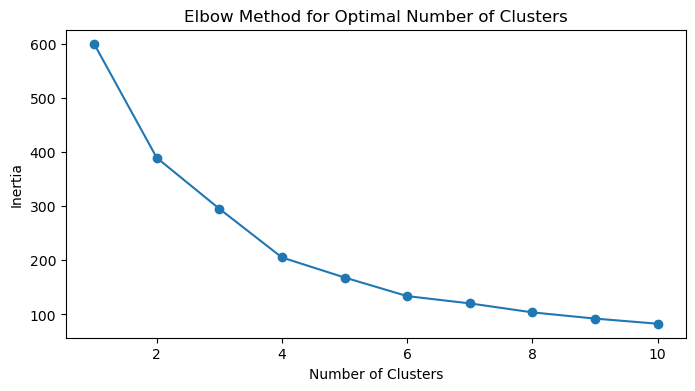

Silhouette Score: 0.4039582785148566


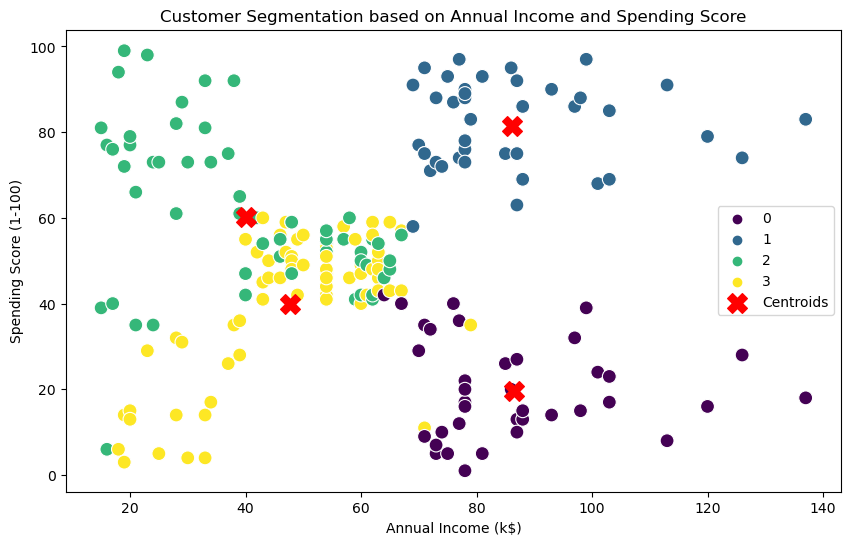

In [4]:
"""
Program to implement customer segmentation using K-Means clustering on the Mall Customers dataset.
Developed by: THENAMUDHEN S
Register Number: 212225040471
"""

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings

warnings.filterwarnings("ignore")

# Load dataset
data = pd.read_csv('CustomerData (2).csv')

print(data.head())
print(data.columns)

# Select features
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = data[features]

# Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method
inertia_values = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), inertia_values, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.show()

# Optimal clusters
optimal_clusters = 4
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42, n_init=10)
kmeans.fit(X_scaled)

data['Cluster'] = kmeans.labels_

# Silhouette score
sil_score = silhouette_score(X_scaled, kmeans.labels_)
print("Silhouette Score:", sil_score)

# Visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=data,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='viridis',
    s=100
)

# Plot centroids
centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centers[:, 1],
    centers[:, 2],
    c='red',
    s=200,
    marker='X',
    label='Centroids'
)

plt.title('Customer Segmentation based on Annual Income and Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()